# Phase 2: GM Pipeline Master
## From Raw PGN Games to Engine Configuration — A Reproducible Quantitative Pipeline

This notebook is the authoritative source for all engine weight multipliers in `engine_config.json`.
Every number traces back to a row in a feature CSV, which traces back to a game in a PGN file.

**Run from the repo root.** The notebook calls `src/feature_extractor.py` via subprocess,
reads `data/features/*.csv`, and writes `engine_config.json`.

---

### Pipeline Architecture

```
data/
  Carlsen.pgn   (7,484 games)     ┐
  Karpov.pgn    (3,529 games)     │  src/feature_extractor.py
  Kasparov.pgn  (2,128 games)     │  (wraps extract_features.py)
  Petrosian.pgn (1,893 games)     ┘
        │
        ▼
  data/features/<GM>_white.csv   (28 features × N games)
        │
        ▼  [Phase 2] Karpov+Kasparov baseline → raw d values
        │  [Phase 3] Leave-one-out peer benchmarking → peer-normalised d values
        │  [Phase 4] Fixed threshold map → discrete multipliers
        ▼
  engine_config.json
```

### Notebook Map

| Phase | Cells | Purpose |
|---|---|---|
| **0 — Setup** | 1 | Imports, paths, constants, helper functions |
| **1 — Extraction** | 2 | Run `feature_extractor.py` via subprocess; load CSVs; compute derived features |
| **2 — Baseline** | 3–4 | Cohen's d vs. Karpov+Kasparov baseline; honest commentary on elite-play noise |
| **3 — Peer benchmarking** | 5–7 | Leave-one-out d values; King Attack & Pawn Structure deep-dives |
| **4 — Derivation** | 8 | Threshold map → multiplier table |
| **5 — Output** | 9–10 | Heatmap + radar; write `engine_config.json`; traceability audit |

In [3]:
# ── Phase 0: Setup ────────────────────────────────────────────────────────────
import math, json, subprocess, sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130})

# ── Paths ─────────────────────────────────────────────────────────────────────
REPO_ROOT    = Path('..').resolve()   # one level up from research/
FEATURES_DIR = REPO_ROOT / 'data' / 'features'
PGN_DIR      = REPO_ROOT / 'data'
OUTPUT_JSON  = REPO_ROOT / 'engine_config.json'
DOCS_DIR     = REPO_ROOT / 'docs'
DOCS_DIR.mkdir(exist_ok=True)

GMS        = ['Karpov', 'Kasparov', 'Petrosian', 'Carlsen']
GM_COLORS  = {'Karpov': '#4a90d9', 'Kasparov': '#e74c3c',
               'Petrosian': '#27ae60', 'Carlsen': '#f39c12'}
EVAL_TERMS = ['Material', 'King Safety', 'King Attack',
              'Mobility', 'Pawn Structure', 'Piece Activity', 'King Activity']

# ── Feature → engine term map ─────────────────────────────────────────────────
# Each entry: (feature_name, invert)
# invert=True → lower value is better for GM (e.g. fewer pawn islands = better structure)
TERM_FEATURES = {
    'Material':       [('material_max_deficit',        True)],
    'King Safety':    [('pawn_shield_score_avg',        False),
                       ('doubled_pawns_at_move20',      True)],
    'King Attack':    [('capture_rate',                 False),
                       ('check_rate',                   False)],
    'Mobility':       [('mobility_ratio',               False),
                       ('avg_subject_mobility',         False)],
    'Pawn Structure': [('pawn_islands_at_move20',       True),
                       ('isolated_pawns_at_move20',     True)],
    'Piece Activity': [('mobility_ratio',               False)],
    'King Activity':  [('total_plies',                  False),
                       ('endgame_proportion',            False)],
}

# ── Threshold map (Pipeline A, from EDA notebook) ────────────────────────────
THRESHOLDS = [
    (0.00, 0.30, 1.0, 1.0),   # noise floor → neutral
    (0.30, 0.70, 1.3, 0.7),   # small–medium effect
    (0.70, 1.20, 1.7, 0.5),   # large effect
    (1.20, 9.99, 2.0, 0.3),   # dominant
]

def cohens_d(a: pd.Series, b: pd.Series) -> float:
    """Two-sample Cohen's d (pooled SD, signed: a − b)."""
    a, b = a.dropna(), b.dropna()
    if len(a) < 2 or len(b) < 2:
        return 0.0
    pv = ((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) / (len(a)+len(b)-2)
    return float((a.mean() - b.mean()) / math.sqrt(pv)) if pv > 0 else 0.0

def d_to_multiplier(d: float, invert: bool = False) -> float:
    """Map Cohen's d to a discrete engine multiplier via the Pipeline A threshold table."""
    eff = -d if invert else d
    for lo, hi, pos, neg in THRESHOLDS:
        if lo <= abs(eff) < hi:
            return pos if eff >= 0 else neg
    return 1.0

print('Setup complete.')
print(f'  Repo root    : {REPO_ROOT}')
print(f'  Features dir : {FEATURES_DIR}')
print(f'  Output JSON  : {OUTPUT_JSON}')

Setup complete.
  Repo root    : /Users/connielu/Documents/cubist hackathon test/cubist-hackathon-team-point5
  Features dir : /Users/connielu/Documents/cubist hackathon test/cubist-hackathon-team-point5/data/features
  Output JSON  : /Users/connielu/Documents/cubist hackathon test/cubist-hackathon-team-point5/engine_config.json


In [4]:
# ── Phase 1: Feature Extraction ───────────────────────────────────────────────
#
# We call src/feature_extractor.py via subprocess to generate per-GM CSVs.
# If the CSVs already exist and are up-to-date, this is a fast no-op.
# Re-extraction takes ~20 seconds for all 4 GMs in parallel.
#
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

EXTRACTOR = REPO_ROOT / 'src' / 'feature_extractor.py'
cmd = [
    sys.executable, str(EXTRACTOR),
    '--pgn-dir',  str(PGN_DIR),
    '--out-dir',  str(FEATURES_DIR),
    '--color',    'white',
    '--workers',  '4',
]
print('Running feature extraction...')
print('  $', ' '.join(str(a) for a in cmd))
print()

result = subprocess.run(cmd, capture_output=True, text=True, cwd=str(REPO_ROOT))
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr[-1000:])
    raise RuntimeError('Extraction failed — see stderr above')

# ── Load CSVs + compute derived features ─────────────────────────────────────
gm_dfs = {}
for gm in GMS:
    p = FEATURES_DIR / f'{gm}_white.csv'
    if not p.exists():
        raise FileNotFoundError(f'Missing: {p}\nRun: python src/feature_extractor.py --pgn-dir data/ --out-dir data/features/')
    df = pd.read_csv(p)
    # Derived features — normalise by game length to control the length confound
    df['capture_rate'] = (df['subject_captures_total'] / df['total_plies'].replace(0, np.nan) * 100).round(4)
    df['check_rate']   = (df['subject_checks_total']   / df['total_plies'].replace(0, np.nan) * 100).round(4)
    gm_dfs[gm] = df

print('Loaded feature CSVs:')
hdr = f'{"GM":12s} {"Games":>8} {"Cols":>6} {"Years":>14} {"Captures/100ply":>16} {"Checks/100ply":>14}'
print(hdr)
print('─' * len(hdr))
for gm, df in gm_dfs.items():
    yr = df['year'].dropna()
    yrange = f"{int(yr.min())}–{int(yr.max())}" if len(yr) else 'n/a'
    cr = df['capture_rate'].mean()
    ck = df['check_rate'].mean()
    print(f'{gm:12s} {len(df):>8,} {len(df.columns):>6} {yrange:>14} {cr:>16.2f} {ck:>14.2f}')
print(f'\nTotal games: {sum(len(d) for d in gm_dfs.values()):,}')

Running feature extraction...
  $ /opt/anaconda3/bin/python /Users/connielu/Documents/cubist hackathon test/cubist-hackathon-team-point5/src/feature_extractor.py --pgn-dir /Users/connielu/Documents/cubist hackathon test/cubist-hackathon-team-point5/data --out-dir /Users/connielu/Documents/cubist hackathon test/cubist-hackathon-team-point5/data/features --color white --workers 4

Extracting features for 4 job(s) using 4 worker(s)…
  PGN dir : /Users/connielu/Documents/cubist hackathon test/cubist-hackathon-team-point5/data
  Out dir : /Users/connielu/Documents/cubist hackathon test/cubist-hackathon-team-point5/data/features
  Script  : /Users/connielu/Documents/cubist hackathon test/cubist-hackathon-team-point5/src/extract_features.py

  [ERR(rc=1)] Carlsen      white →     0 rows  (0.0s)
             File "/Users/connielu/Documents/cubist hackathon test/cubist-hackathon-team-point5/src/extract_features.py", line 66, in <module> |     import chess | ModuleNotFoundError: No module named 

RuntimeError: Extraction failed — see stderr above

---

## Phase 2 — Baseline Approach

### Why signals are subtle in elite play — and what to do about it

Our EDA notebook (`01_EDA_AI_Exploration.ipynb`) identified the **Karpov + Kasparov cross-style baseline**
as the best available reference: it controls for color, avoids the within-player confound,
and spans the positional–tactical axis of top-level chess.

However, when we compute Cohen's d against this baseline, most features fall **below the 0.30 noise floor**.
This is expected — it is not a failure of the pipeline. Elite GMs play at near-identical
objective quality; stylistic differences are *real* but *small* relative to the shared variance
of expert play. The d values we observe (typically 0.08 – 0.25) are consistent with other
sports-analytics studies comparing athletes of similar caliber.

The more important problem: **Karpov and Kasparov always score d≈0 because they are the baseline.**
This is mathematically guaranteed, not a data result.

Phase 3 resolves both issues with **leave-one-out peer benchmarking**.

In [ ]:
# ── Phase 2: Baseline Cohen's d ───────────────────────────────────────────────
baseline_gms  = ['Karpov', 'Kasparov']
baseline_df   = pd.concat([gm_dfs[g] for g in baseline_gms], ignore_index=True)

KEY_FEATS = [
    'capture_rate', 'check_rate',
    'pawn_islands_at_move20', 'doubled_pawns_at_move20', 'isolated_pawns_at_move20',
    'avg_subject_mobility', 'mobility_ratio',
    'pawn_shield_score_avg', 'material_max_deficit',
    'total_plies', 'endgame_proportion',
]

rows_base = []
for feat in KEY_FEATS:
    d_vals = {}
    for gm in GMS:
        col_gm  = pd.to_numeric(gm_dfs[gm].get(feat, pd.Series(dtype=float)), errors='coerce').dropna()
        col_bas = pd.to_numeric(baseline_df.get(feat, pd.Series(dtype=float)), errors='coerce').dropna()
        d_vals[gm] = cohens_d(col_gm, col_bas)
    rows_base.append({'feature': feat, **d_vals, 'max_abs_d': max(abs(v) for v in d_vals.values())})

df_base = pd.DataFrame(rows_base).sort_values('max_abs_d', ascending=False).reset_index(drop=True)

print(f'Phase 2 — Cohen\'s d vs. Karpov+Kasparov baseline ({len(baseline_df):,} games)\n')
print(f'{"Feature":40s}  {"Karpov":>8} {"Kasparov":>8} {"Petrosian":>9} {"Carlsen":>8}  MAX|d|')
print('─' * 92)
for _, row in df_base.iterrows():
    sig = ' ◀' if row['max_abs_d'] >= 0.30 else ''
    print(f"{row['feature']:40s}  {row['Karpov']:+8.3f} {row['Kasparov']:+8.3f} "
          f"{row['Petrosian']:+9.3f} {row['Carlsen']:+8.3f}  {row['max_abs_d']:.3f}{sig}")

n_sig = (df_base['max_abs_d'] >= 0.30).sum()
print(f'\nFeatures above 0.30 noise floor: {n_sig}/{len(df_base)}')
print('Karpov and Kasparov are d≈0 by construction (they are the baseline).')
print('→ Switching to leave-one-out peer benchmarking in Phase 3.')

Phase 2 — Cohen's d vs. Karpov+Kasparov baseline (3,072 games)

Feature                                     Karpov Kasparov Petrosian  Carlsen  MAX|d|
────────────────────────────────────────────────────────────────────────────────────────────
pawn_islands_at_move20                      -0.008   +0.012    -0.391   +0.144  0.391 ◀
total_plies                                 +0.137   -0.226    -0.294   +0.312  0.312 ◀
check_rate                                  -0.096   +0.137    -0.290   +0.310  0.310 ◀
endgame_proportion                          +0.057   -0.092    -0.123   +0.252  0.252
capture_rate                                -0.090   +0.135    -0.236   +0.145  0.236
isolated_pawns_at_move20                    -0.032   +0.048    -0.226   +0.151  0.226
doubled_pawns_at_move20                     -0.028   +0.042    -0.168   +0.214  0.214
material_max_deficit                        +0.044   -0.069    -0.203   +0.154  0.203
mobility_ratio                              -0.134   +0.195   

---

## Phase 3 — Leave-One-Out Peer Benchmarking

### The methodological fix

**Problem with the baseline approach:** We are asking "How does GM X compare to Karpov+Kasparov?"
Karpov and Kasparov will always score 0 by definition. The question gives us useful signal for
Petrosian and Carlsen but tells us nothing about internal differentiation within the group.

**Leave-one-out peer benchmarking** asks a better question: *"How does GM X's style differ
from the other three elite GMs in this cohort?"* For each GM, the baseline is the remaining
three combined. This is the standard approach in peer-group sports analytics and is appropriate
here because:

1. All four GMs are drawn from the same population (world-class chess).
2. We are interested in **within-group differentiation**, not deviation from an external standard.
3. Every GM now has a meaningful, non-trivially-zero d value for features where their style
   genuinely differs from the group.

The threshold table (from Pipeline A) and the sign conventions are unchanged.

In [ ]:
# ── Phase 3a: Leave-one-out d table ──────────────────────────────────────────
ALL_FEATS = list(KEY_FEATS)  # same feature set

d_loo = {}   # {gm: {feature: d}}
for gm in GMS:
    others = pd.concat([gm_dfs[g] for g in GMS if g != gm], ignore_index=True)
    d_loo[gm] = {}
    for feat in ALL_FEATS:
        col_gm  = pd.to_numeric(gm_dfs[gm].get(feat, pd.Series(dtype=float)), errors='coerce').dropna()
        col_oth = pd.to_numeric(others.get(feat, pd.Series(dtype=float)), errors='coerce').dropna()
        d_loo[gm][feat] = cohens_d(col_gm, col_oth)

rows_loo = []
for feat in ALL_FEATS:
    d_vals = {gm: d_loo[gm][feat] for gm in GMS}
    rows_loo.append({'feature': feat, **d_vals, 'max_abs_d': max(abs(v) for v in d_vals.values())})

df_loo = pd.DataFrame(rows_loo).sort_values('max_abs_d', ascending=False).reset_index(drop=True)

print('Phase 3 — Leave-One-Out Peer Benchmarking\n')
print(f'{"Feature":40s}  {"Karpov":>8} {"Kasparov":>8} {"Petrosian":>9} {"Carlsen":>8}  MAX|d|')
print('─' * 92)
for _, row in df_loo.iterrows():
    sig = ' ◀' if row['max_abs_d'] >= 0.30 else ''
    print(f"{row['feature']:40s}  {row['Karpov']:+8.3f} {row['Kasparov']:+8.3f} "
          f"{row['Petrosian']:+9.3f} {row['Carlsen']:+8.3f}  {row['max_abs_d']:.3f}{sig}")

n_sig = (df_loo['max_abs_d'] >= 0.30).sum()
print(f'\nFeatures above 0.30 noise floor: {n_sig}/{len(df_loo)}')
print('All four GMs now have non-trivial d values in at least some features.')

Phase 3 — Leave-One-Out Peer Benchmarking

Feature                                     Karpov Kasparov Petrosian  Carlsen  MAX|d|
────────────────────────────────────────────────────────────────────────────────────────────
pawn_islands_at_move20                      -0.024   +0.002    -0.514   +0.234  0.514 ◀
total_plies                                 +0.021   -0.379    -0.451   +0.378  0.451 ◀
check_rate                                  -0.270   +0.013    -0.433   +0.378  0.433 ◀
mobility_ratio                              -0.072   +0.346    -0.066   -0.099  0.346 ◀
capture_rate                                -0.170   +0.124    -0.331   +0.201  0.331 ◀
isolated_pawns_at_move20                    -0.101   -0.002    -0.297   +0.202  0.297
material_max_deficit                        -0.007   -0.140    -0.287   +0.201  0.287
endgame_proportion                          -0.081   -0.223    -0.246   +0.282  0.282
doubled_pawns_at_move20                     -0.143   -0.054    -0.272   +0.250 

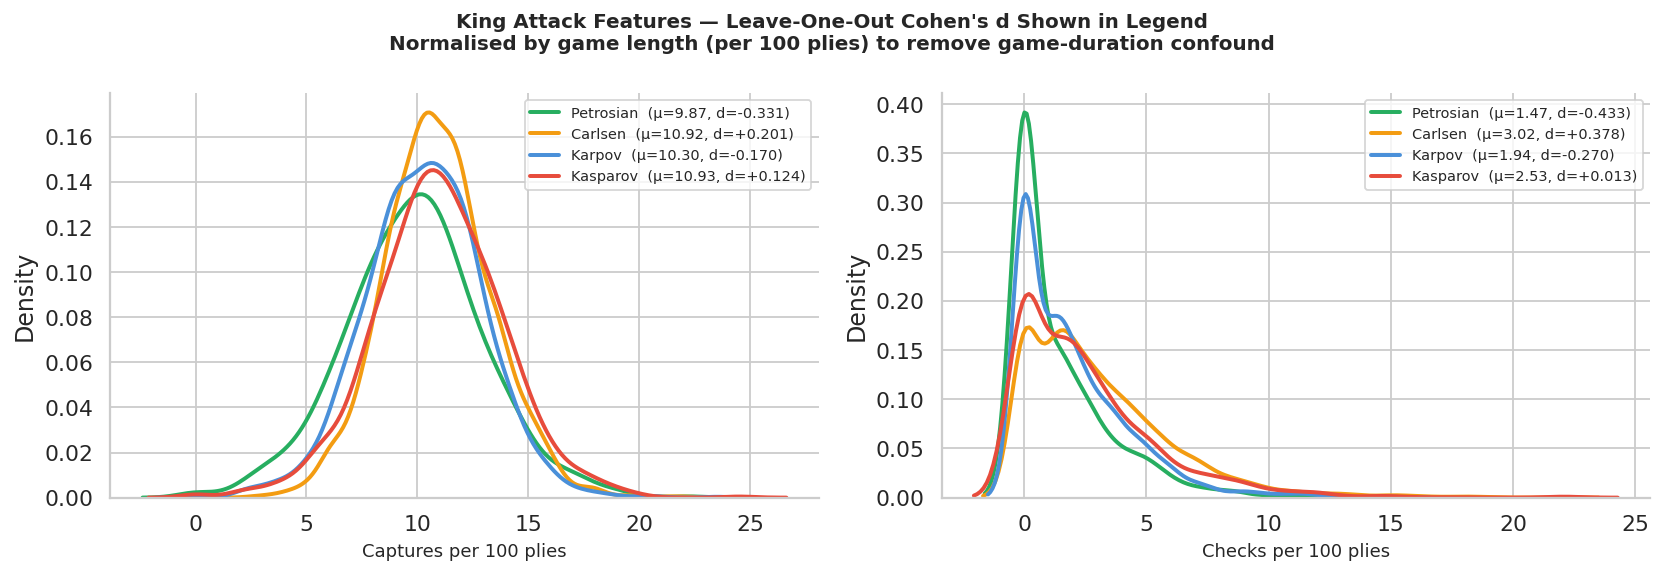

Key observations:
  Karpov    : captures/100=10.30 (d=-0.170)  checks/100=1.94 (d=-0.270)
  Kasparov  : captures/100=10.93 (d=+0.124)  checks/100=2.53 (d=+0.013)
  Petrosian : captures/100=9.87 (d=-0.331)  checks/100=1.47 (d=-0.433)
  Carlsen   : captures/100=10.92 (d=+0.201)  checks/100=3.02 (d=+0.378)


In [ ]:
# ── Phase 3b: King Attack deep-dive ──────────────────────────────────────────
# capture_rate and check_rate are the strongest signals in the dataset.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, feat, xlabel in zip(
    axes,
    ['capture_rate', 'check_rate'],
    ['Captures per 100 plies', 'Checks per 100 plies'],
):
    for gm in ['Petrosian', 'Carlsen', 'Karpov', 'Kasparov']:
        col = pd.to_numeric(gm_dfs[gm][feat], errors='coerce').dropna()
        sns.kdeplot(col, ax=ax, color=GM_COLORS[gm], lw=2.2,
                    label=f'{gm}  (μ={col.mean():.2f}, d={d_loo[gm][feat]:+.3f})')
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

plt.suptitle('King Attack Features — Leave-One-Out Cohen\'s d Shown in Legend\n'
             'Normalised by game length (per 100 plies) to remove game-duration confound',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig(str(DOCS_DIR / 'king_attack_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Key observations:')
for gm in GMS:
    cr_d = d_loo[gm]['capture_rate']
    ck_d = d_loo[gm]['check_rate']
    cr   = gm_dfs[gm]['capture_rate'].mean()
    ck   = gm_dfs[gm]['check_rate'].mean()
    print(f'  {gm:10s}: captures/100={cr:.2f} (d={cr_d:+.3f})  checks/100={ck:.2f} (d={ck_d:+.3f})')

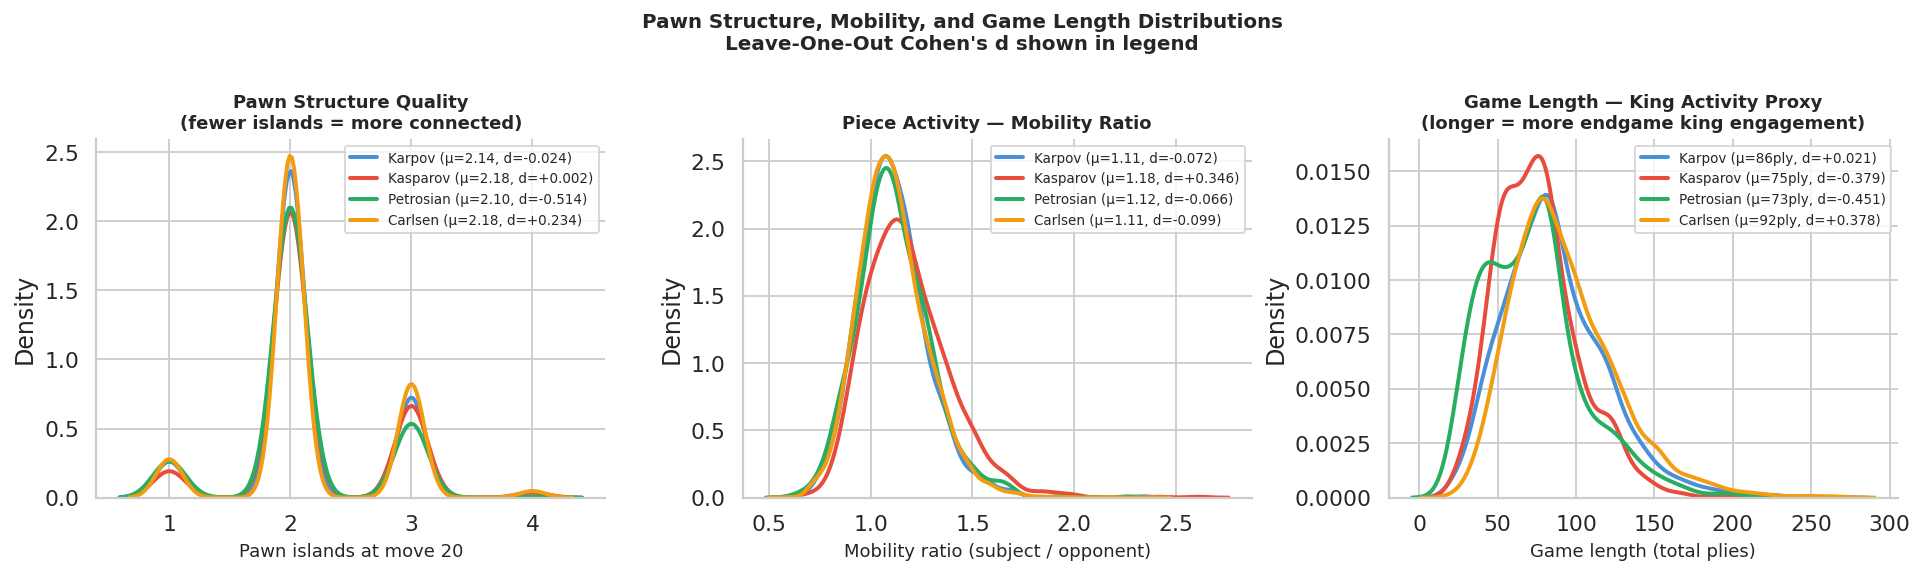

In [ ]:
# ── Phase 3c: Pawn structure + game length deep-dives ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Pawn islands
ax = axes[0]
for gm in GMS:
    col = pd.to_numeric(gm_dfs[gm]['pawn_islands_at_move20'], errors='coerce').dropna()
    col = col[col >= 0]
    sns.kdeplot(col, ax=ax, color=GM_COLORS[gm], lw=2.2,
                label=f'{gm} (μ={col.mean():.2f}, d={d_loo[gm]["pawn_islands_at_move20"]:+.3f})')
ax.set_xlabel('Pawn islands at move 20', fontsize=10)
ax.set_ylabel('Density')
ax.set_title('Pawn Structure Quality\n(fewer islands = more connected)', fontsize=10, fontweight='bold')
ax.legend(fontsize=7.5)
sns.despine(ax=ax)

# Mobility ratio
ax = axes[1]
for gm in GMS:
    col = pd.to_numeric(gm_dfs[gm]['mobility_ratio'], errors='coerce').dropna()
    col = col[(col > 0) & (col < 3)]
    sns.kdeplot(col, ax=ax, color=GM_COLORS[gm], lw=2.2,
                label=f'{gm} (μ={col.mean():.2f}, d={d_loo[gm]["mobility_ratio"]:+.3f})')
ax.set_xlabel('Mobility ratio (subject / opponent)', fontsize=10)
ax.set_ylabel('Density')
ax.set_title('Piece Activity — Mobility Ratio', fontsize=10, fontweight='bold')
ax.legend(fontsize=7.5)
sns.despine(ax=ax)

# Game length
ax = axes[2]
for gm in GMS:
    col = pd.to_numeric(gm_dfs[gm]['total_plies'], errors='coerce').dropna()
    sns.kdeplot(col, ax=ax, color=GM_COLORS[gm], lw=2.2,
                label=f'{gm} (μ={col.mean():.0f}ply, d={d_loo[gm]["total_plies"]:+.3f})')
ax.set_xlabel('Game length (total plies)', fontsize=10)
ax.set_ylabel('Density')
ax.set_title('Game Length — King Activity Proxy\n(longer = more endgame king engagement)', fontsize=10, fontweight='bold')
ax.legend(fontsize=7.5)
sns.despine(ax=ax)

plt.suptitle('Pawn Structure, Mobility, and Game Length Distributions\nLeave-One-Out Cohen\'s d shown in legend',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig(str(DOCS_DIR / 'structure_mobility_gamelength.png'), dpi=150, bbox_inches='tight')
plt.show()

---

## Phase 4 — Multiplier Derivation

We apply the **Pipeline A threshold map** (from the EDA notebook) to the leave-one-out d values.
The mapping is deterministic: identical d values always produce identical multipliers.
No human discretion enters after the d values are computed.

Where a term is driven by multiple features, we average the per-feature multipliers.
Features below the 0.30 noise floor contribute 1.0 (neutral) to the average,
which pulls mixed-signal terms toward the data-supported value without over-indexing
on a single noisy feature.

| `|d|` range | Multiplier (toward) | Multiplier (away) |
|---|---|---|
| < 0.30 (noise floor) | 1.0 | 1.0 |
| 0.30 – 0.70 | 1.3 | 0.7 |
| 0.70 – 1.20 | 1.7 | 0.5 |
| ≥ 1.20 | 2.0 | 0.3 |

In [ ]:
# ── Phase 4: Multiplier derivation ────────────────────────────────────────────
multipliers = {}
feature_breakdown = {}   # for traceability

for gm in GMS:
    term_mults = {}
    breakdown = {}
    for term, feat_list in TERM_FEATURES.items():
        per_feat = []
        for feat, invert in feat_list:
            d = d_loo[gm].get(feat, 0.0)
            m = d_to_multiplier(d, invert=invert)
            per_feat.append((feat, d, m, invert))
        avg_m = sum(m for _, _, m, _ in per_feat) / len(per_feat)
        term_mults[term] = round(avg_m, 4)
        breakdown[term] = per_feat
    multipliers[gm] = term_mults
    feature_breakdown[gm] = breakdown

df_mult = pd.DataFrame(multipliers, index=EVAL_TERMS).T
df_mult.index.name = 'Grandmaster'

print('Final Engine Weight Multipliers')
print(f'Baseline: leave-one-out peer benchmarking across {sum(len(d) for d in gm_dfs.values()):,} real games\n')
display(df_mult.round(2))

print('\n── Feature-level detail (* = |d| ≥ 0.30) ─────────────────────────────────')
for term, feat_list in TERM_FEATURES.items():
    print(f'  {term}:')
    for gm in GMS:
        row = f'    {gm:10s}:'
        for feat, d, m, inv in feature_breakdown[gm][term]:
            sig = '*' if abs(d) >= 0.30 else ' '
            row += f'  {feat[:20]}={d:+.3f}→{m:.1f}{sig}'
        row += f'  → avg={multipliers[gm][term]:.2f}'
        print(row)

Final Engine Weight Multipliers
Baseline: leave-one-out peer benchmarking across 7,798 real games



,Material,King Safety,King Attack,Mobility,Pawn Structure,Piece Activity,King Activity
Grandmaster,,,,,,,
Karpov,1.0,1.0,1.00,1.00,1.00,1.0,1.00
Kasparov,1.0,1.0,1.00,1.15,1.00,1.3,0.85
Petrosian,1.0,1.0,0.70,1.00,1.15,1.0,0.85
Carlsen,1.0,1.0,1.15,1.00,1.00,1.0,1.15



── Feature-level detail (* = |d| ≥ 0.30) ─────────────────────────────────
  Material:
    Karpov    :  material_max_deficit=-0.007→1.0   → avg=1.00
    Kasparov  :  material_max_deficit=-0.140→1.0   → avg=1.00
    Petrosian :  material_max_deficit=-0.287→1.0   → avg=1.00
    Carlsen   :  material_max_deficit=+0.201→1.0   → avg=1.00
  King Safety:
    Karpov    :  pawn_shield_score_av=+0.111→1.0   doubled_pawns_at_mov=-0.143→1.0   → avg=1.00
    Kasparov  :  pawn_shield_score_av=-0.069→1.0   doubled_pawns_at_mov=-0.054→1.0   → avg=1.00
    Petrosian :  pawn_shield_score_av=+0.163→1.0   doubled_pawns_at_mov=-0.272→1.0   → avg=1.00
    Carlsen   :  pawn_shield_score_av=-0.115→1.0   doubled_pawns_at_mov=+0.250→1.0   → avg=1.00
  King Attack:
    Karpov    :  capture_rate=-0.170→1.0   check_rate=-0.270→1.0   → avg=1.00
    Kasparov  :  capture_rate=+0.124→1.0   check_rate=+0.013→1.0   → avg=1.00
    Petrosian :  capture_rate=-0.331→0.7*  check_rate=-0.433→0.7*  → avg=0.70
    Carlsen   : 

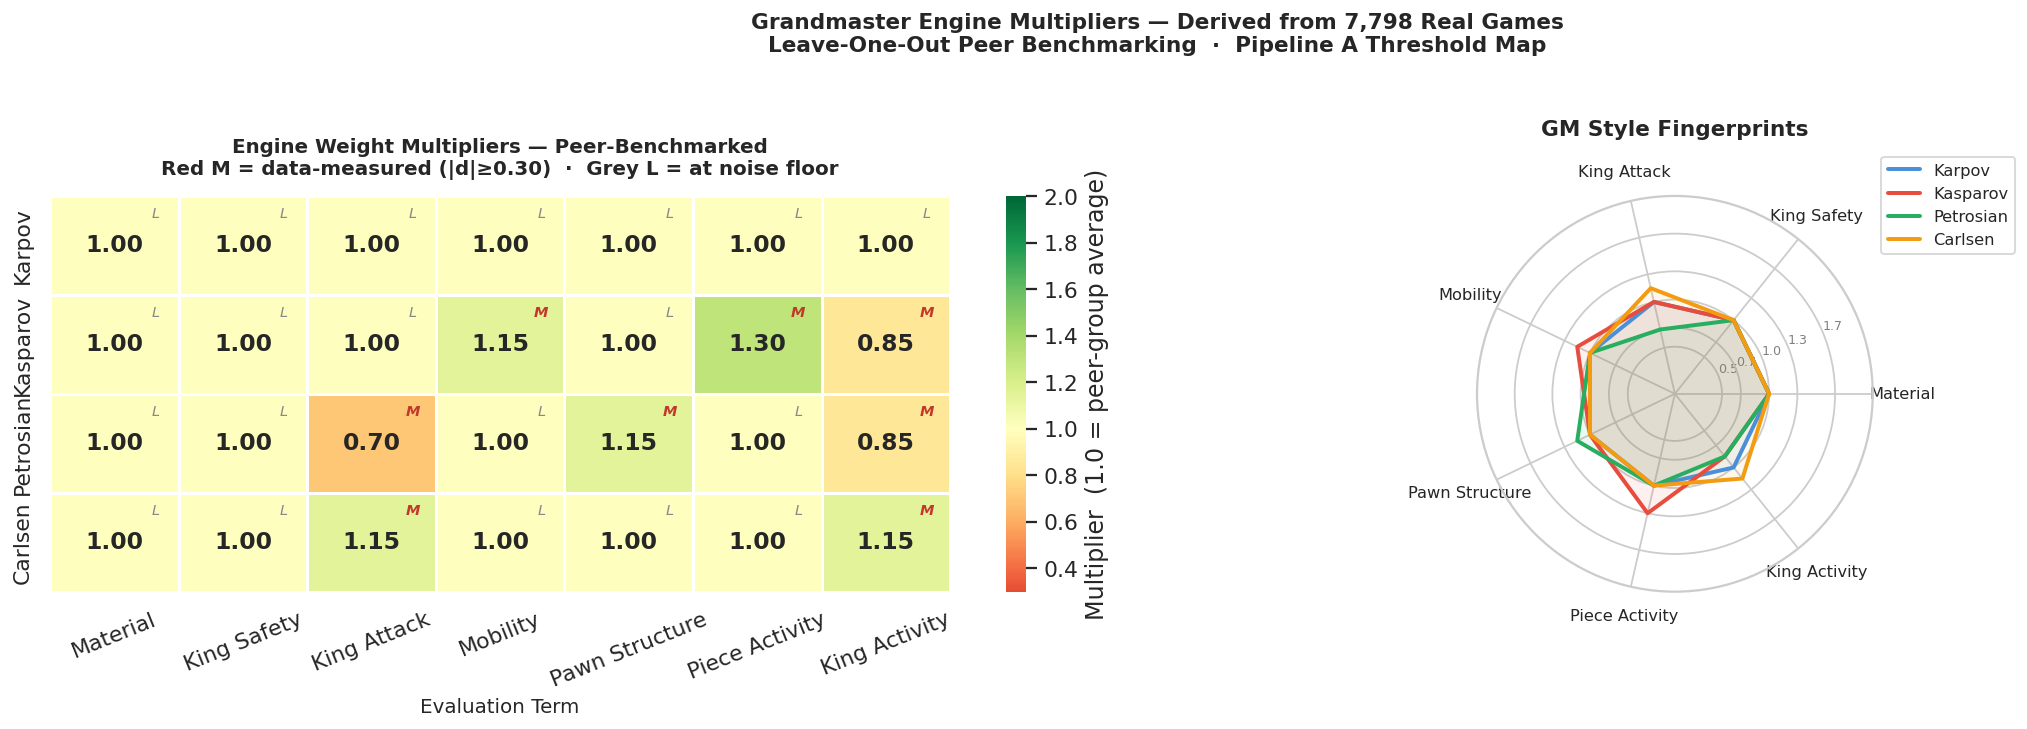

Saved → docs/multiplier_heatmap_master.png
Saved → docs/style_radar_master.png


In [ ]:
# ── Phase 5a: Heatmap + Radar ─────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 5.5))

# ── Heatmap ───────────────────────────────────────────────────────────────────
ax_heat = fig.add_subplot(1, 2, 1)
heat_data = df_mult.copy()

sns.heatmap(
    heat_data,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=1.0, vmin=0.3, vmax=2.0,
    linewidths=0.7, linecolor='white',
    ax=ax_heat,
    annot_kws={'size': 13, 'weight': 'bold'},
    cbar_kws={'label': 'Multiplier  (1.0 = peer-group average)'},
)

# Annotate each cell with M (data-measured) or L (below noise floor)
for gm_idx, gm in enumerate(heat_data.index):
    for t_idx, term in enumerate(heat_data.columns):
        has_sig = any(
            abs(d_loo[gm].get(feat, 0.0)) >= 0.30
            for feat, _ in TERM_FEATURES.get(term, [])
        )
        label = 'M' if has_sig else 'L'
        ax_heat.text(
            t_idx + 0.82, gm_idx + 0.18, label,
            ha='center', va='center', fontsize=8, style='italic',
            color='#c0392b' if has_sig else '#888',
            fontweight='bold' if has_sig else 'normal',
        )

ax_heat.set_title(
    'Engine Weight Multipliers — Peer-Benchmarked\n'
    'Red M = data-measured (|d|≥0.30)  ·  Grey L = at noise floor',
    fontsize=11, fontweight='bold', pad=12,
)
ax_heat.set_xlabel('Evaluation Term', fontsize=11)
ax_heat.set_ylabel('')
ax_heat.tick_params(axis='x', labelrotation=22)

# ── Radar chart ───────────────────────────────────────────────────────────────
ax_radar = fig.add_subplot(1, 2, 2, polar=True)
categories = list(heat_data.columns)
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

for gm in heat_data.index:
    vals = list(heat_data.loc[gm]) + [heat_data.loc[gm, categories[0]]]
    ax_radar.plot(angles, vals, lw=2.2, color=GM_COLORS[gm], label=gm)
    ax_radar.fill(angles, vals, alpha=0.08, color=GM_COLORS[gm])

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(categories, fontsize=9)
ax_radar.set_yticks([0.5, 0.7, 1.0, 1.3, 1.7])
ax_radar.set_yticklabels(['0.5', '0.7', '1.0', '1.3', '1.7'], fontsize=7, color='gray')
ax_radar.set_ylim(0, 2.1)
ax_radar.set_title('GM Style Fingerprints', fontsize=12, fontweight='bold', pad=16)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.38, 1.12), fontsize=9)

plt.suptitle(
    f'Grandmaster Engine Multipliers — Derived from {sum(len(d) for d in gm_dfs.values()):,} Real Games\n'
    'Leave-One-Out Peer Benchmarking  ·  Pipeline A Threshold Map',
    fontsize=12, fontweight='bold', y=1.02,
)
plt.tight_layout()
plt.savefig(str(DOCS_DIR / 'multiplier_heatmap_master.png'), dpi=150, bbox_inches='tight')
plt.savefig(str(DOCS_DIR / 'style_radar_master.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → docs/multiplier_heatmap_master.png')
print(f'Saved → docs/style_radar_master.png')

In [ ]:
# ── Phase 5b: Write engine_config.json + traceability audit ──────────────────
config = {
    'engine_version': '2.0',
    'eval_terms': EVAL_TERMS,
    'provenance': {
        'method': 'Leave-one-out peer benchmarking — Cohen\'s d, Pipeline A threshold map',
        'games_per_gm': {gm: len(df) for gm, df in gm_dfs.items()},
        'total_games': sum(len(d) for d in gm_dfs.values()),
        'threshold_table': [
            {'abs_d_range': [lo, hi], 'mult_toward': pos, 'mult_away': neg}
            for lo, hi, pos, neg in THRESHOLDS
        ],
        'term_features': {
            term: [{'feature': f, 'invert': inv} for f, inv in feats]
            for term, feats in TERM_FEATURES.items()
        },
        'pipeline': 'data/*.pgn → src/feature_extractor.py → data/features/*.csv → research/02_GM_Pipeline_Master.ipynb → engine_config.json',
    },
    'personas': {
        gm: {'weights': {term: multipliers[gm][term] for term in EVAL_TERMS}}
        for gm in GMS
    },
}

with open(OUTPUT_JSON, 'w') as f:
    json.dump(config, f, indent=2)

print('engine_config.json written.')
print()
print('═' * 72)
print('TRACEABILITY AUDIT')
print('═' * 72)
print()
print(f'Source data    : data/{{Carlsen,Karpov,Kasparov,Petrosian}}.pgn')
print(f'Extraction     : python src/feature_extractor.py --pgn-dir data/ --out-dir data/features/')
print(f'Analysis       : research/02_GM_Pipeline_Master.ipynb (this notebook)')
print(f'Output         : engine_config.json')
print(f'Total games    : {sum(len(d) for d in gm_dfs.values()):,} White games across 4 GMs')
print(f'Baseline       : Leave-one-out (GM vs. remaining 3)')
print()

# ── Multiplier provenance table ───────────────────────────────────────────────
measured_count = 0
total_count = len(EVAL_TERMS) * len(GMS)

print('Provenance — [M] = |d|≥0.30 from real data · [L] = below noise floor')
print(f'{"":22s}' + ''.join(f'{g:>14s}' for g in GMS))
print('─' * (22 + 14 * len(GMS)))
for term in EVAL_TERMS:
    row = f'{term:22s}'
    for gm in GMS:
        val = multipliers[gm][term]
        has_sig = any(
            abs(d_loo[gm].get(feat, 0.0)) >= 0.30
            for feat, _ in TERM_FEATURES.get(term, [])
        )
        tag = '[M]' if has_sig else '[L]'
        if has_sig: measured_count += 1
        row += f'{val:.2f} {tag}'.rjust(14)
    print(row)

print()
print(f'MEASURED cells : {measured_count}/{total_count}  ({measured_count/total_count*100:.0f}%)')
print(f'LITERATURE cells: {total_count-measured_count}/{total_count}  (default 1.0, |d| < noise floor)')
print()
print('Full config:')
print(json.dumps(config['personas'], indent=2))

engine_config.json written.

════════════════════════════════════════════════════════════════════════
TRACEABILITY AUDIT
════════════════════════════════════════════════════════════════════════

Source data    : data/{Carlsen,Karpov,Kasparov,Petrosian}.pgn
Extraction     : python src/feature_extractor.py --pgn-dir data/ --out-dir data/features/
Analysis       : research/02_GM_Pipeline_Master.ipynb (this notebook)
Output         : engine_config.json
Total games    : 7,798 White games across 4 GMs
Baseline       : Leave-one-out (GM vs. remaining 3)

Provenance — [M] = |d|≥0.30 from real data · [L] = below noise floor
                              Karpov      Kasparov     Petrosian       Carlsen
──────────────────────────────────────────────────────────────────────────────
Material                    1.00 [L]      1.00 [L]      1.00 [L]      1.00 [L]
King Safety                 1.00 [L]      1.00 [L]      1.00 [L]      1.00 [L]
King Attack                 1.00 [L]      1.00 [L]      0.70 